In [1]:
# Data Exploration and Cleaning
# Load the dataset into a Pandas DataFrame and display the first 5 rows.
# Check the shape, column names, and summary statistics of the dataset.
# Identify and handle missing values (fill or drop based on the data type).
# Convert Transaction_Date into datetime format and extract year, month, and day as new columns.


In [2]:
import pandas as pd

In [3]:
# Load the dataset into a Pandas DataFrame and display the first 5 rows.
data = pd.read_csv("credit_card_transactions.csv")
data.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Type,Merchant,Category,Amount,Payment_Mode,Transaction_Status,Location
0,100000,4452,2023-01-01,Online,Walmart,Travel,4520.70,Debit Card,Approved,Jonesport
1,100001,2775,2023-01-01,ATM,BestBuy,Travel,1437.85,Debit Card,Approved,Port Jennifer
2,100002,2259,2023-01-01,Mobile Payment,Uber,Clothing,3320.52,PayPal,Approved,Port James
3,100003,4545,2023-01-01,Online,BestBuy,Travel,2659.96,Debit Card,Approved,Hawkinston
4,100004,2137,2023-01-01,ATM,Amazon,Travel,2517.07,Debit Card,Approved,Matthewland


In [4]:
# Check the shape, column names, and summary statistics of the dataset.
print(data.shape) #(Row,Columns)
print(data.columns.to_list())
print("summary statistics \n ",data.describe())

(5500, 10)
['Transaction_ID', 'Customer_ID', 'Transaction_Date', 'Transaction_Type', 'Merchant', 'Category', 'Amount', 'Payment_Mode', 'Transaction_Status', 'Location']
summary statistics 
         Transaction_ID  Customer_ID       Amount
count     5500.000000  5500.000000  5490.000000
mean    102749.500000  2989.954182  2491.062299
std       1587.857571  1153.928878  1444.542432
min     100000.000000  1000.000000     6.550000
25%     101374.750000  1988.000000  1236.402500
50%     102749.500000  3000.000000  2502.405000
75%     104124.250000  3990.000000  3765.420000
max     105499.000000  4998.000000  4997.490000


In [5]:
# Check DataTypes
data.dtypes

Transaction_ID          int64
Customer_ID             int64
Transaction_Date          str
Transaction_Type          str
Merchant                  str
Category                  str
Amount                float64
Payment_Mode              str
Transaction_Status        str
Location                  str
dtype: object

In [6]:
# Identify and handle missing values (fill or drop based on the data type).
print(data.isnull().sum())

Transaction_ID         0
Customer_ID            0
Transaction_Date       0
Transaction_Type       1
Merchant               2
Category               5
Amount                10
Payment_Mode           3
Transaction_Status     2
Location               0
dtype: int64


In [7]:
# Fill the missing values
data["Merchant"] = data["Merchant"].fillna("Unknown")
print(data.isnull().sum())

Transaction_ID         0
Customer_ID            0
Transaction_Date       0
Transaction_Type       1
Merchant               0
Category               5
Amount                10
Payment_Mode           3
Transaction_Status     2
Location               0
dtype: int64


In [8]:
data["Transaction_Type"] = data["Transaction_Type"].fillna("Unknown")
print(data.isnull().sum())

Transaction_ID         0
Customer_ID            0
Transaction_Date       0
Transaction_Type       0
Merchant               0
Category               5
Amount                10
Payment_Mode           3
Transaction_Status     2
Location               0
dtype: int64


In [9]:
data["Category"] = data["Category"].fillna("Unknown")
print(data.isnull().sum())

Transaction_ID         0
Customer_ID            0
Transaction_Date       0
Transaction_Type       0
Merchant               0
Category               0
Amount                10
Payment_Mode           3
Transaction_Status     2
Location               0
dtype: int64


In [10]:
data["Payment_Mode"] = data["Payment_Mode"].fillna("Unknown")
print(data.isnull().sum())

Transaction_ID         0
Customer_ID            0
Transaction_Date       0
Transaction_Type       0
Merchant               0
Category               0
Amount                10
Payment_Mode           0
Transaction_Status     2
Location               0
dtype: int64


In [11]:
data["Transaction_Status"] = data["Transaction_Status"].fillna("Unknown")
print(data.isnull().sum())

Transaction_ID         0
Customer_ID            0
Transaction_Date       0
Transaction_Type       0
Merchant               0
Category               0
Amount                10
Payment_Mode           0
Transaction_Status     0
Location               0
dtype: int64


In [12]:
# Fill int values (Amount Value)
data["Amount"] = data["Amount"].fillna(data["Amount"].median())
print(data.isnull().sum())

Transaction_ID        0
Customer_ID           0
Transaction_Date      0
Transaction_Type      0
Merchant              0
Category              0
Amount                0
Payment_Mode          0
Transaction_Status    0
Location              0
dtype: int64


In [13]:
# Fill the missing values(All TOGETHER)
data["Merchant"] = data["Merchant"].fillna("Unknown")
data["Transaction_Type"] = data["Transaction_Type"].fillna("Unknown")
data["Category"] = data["Category"].fillna("Unknown")
data["Payment_Mode"] = data["Payment_Mode"].fillna("Unknown")
data["Transaction_Status"] = data["Transaction_Status"].fillna("Unknown")

# Fill int values
data["Amount"] = data["Amount"].fillna(data["Amount"].median())
print(data.isnull().sum())

Transaction_ID        0
Customer_ID           0
Transaction_Date      0
Transaction_Type      0
Merchant              0
Category              0
Amount                0
Payment_Mode          0
Transaction_Status    0
Location              0
dtype: int64


In [14]:
# Check DataTypes If DataType Isnt Changed
data.dtypes

Transaction_ID          int64
Customer_ID             int64
Transaction_Date          str
Transaction_Type          str
Merchant                  str
Category                  str
Amount                float64
Payment_Mode              str
Transaction_Status        str
Location                  str
dtype: object

In [15]:
# Convert Transaction_Date into datetime format and extract year, month, and day as new columns.
data["Transaction_Date"] = pd.to_datetime(data["Transaction_Date"])
print(data.dtypes)

Transaction_ID                 int64
Customer_ID                    int64
Transaction_Date      datetime64[us]
Transaction_Type                 str
Merchant                         str
Category                         str
Amount                       float64
Payment_Mode                     str
Transaction_Status               str
Location                         str
dtype: object


In [16]:
# year, month, and day as new columns.
data["Year"] = data["Transaction_Date"].dt.year
data["Month"] = data["Transaction_Date"].dt.month
data["Day"] = data["Transaction_Date"].dt.day

print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Transaction_ID      5500 non-null   int64         
 1   Customer_ID         5500 non-null   int64         
 2   Transaction_Date    5500 non-null   datetime64[us]
 3   Transaction_Type    5500 non-null   str           
 4   Merchant            5500 non-null   str           
 5   Category            5500 non-null   str           
 6   Amount              5500 non-null   float64       
 7   Payment_Mode        5500 non-null   str           
 8   Transaction_Status  5500 non-null   str           
 9   Location            5500 non-null   str           
 10  Year                5500 non-null   int32         
 11  Month               5500 non-null   int32         
 12  Day                 5500 non-null   int32         
dtypes: datetime64[us](1), float64(1), int32(3), int64(2), str(6

In [17]:
data.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Type,Merchant,Category,Amount,Payment_Mode,Transaction_Status,Location,Year,Month,Day
0,100000,4452,2023-01-01,Online,Walmart,Travel,4520.70,Debit Card,Approved,Jonesport,2023,1,1
1,100001,2775,2023-01-01,ATM,BestBuy,Travel,1437.85,Debit Card,Approved,Port Jennifer,2023,1,1
2,100002,2259,2023-01-01,Mobile Payment,Uber,Clothing,3320.52,PayPal,Approved,Port James,2023,1,1
3,100003,4545,2023-01-01,Online,BestBuy,Travel,2659.96,Debit Card,Approved,Hawkinston,2023,1,1
4,100004,2137,2023-01-01,ATM,Amazon,Travel,2517.07,Debit Card,Approved,Matthewland,2023,1,1


In [18]:
#Export data to excel
data.to_csv("Clean_data.csv")

In [19]:
# Data Selection and Indexing
# Retrieve all transactions made in January 2024.
# Find transactions where Amount > 3000 and Transaction_Type is "Online".
# Select only Approved transactions from the dataset.

In [20]:
# Retrieve all transactions made in January 2024.
jan_24 = data[data["Year"] == 2024]
jan_24.head()
# No data for jan 2024 

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Type,Merchant,Category,Amount,Payment_Mode,Transaction_Status,Location,Year,Month,Day


In [21]:
# Retrieve all transactions made in January (2023).
jan_24 = data[(data["Year"] == 2023) & ( data["Month"] == 1)]
print(jan_24.count())

Transaction_ID        744
Customer_ID           744
Transaction_Date      744
Transaction_Type      744
Merchant              744
Category              744
Amount                744
Payment_Mode          744
Transaction_Status    744
Location              744
Year                  744
Month                 744
Day                   744
dtype: int64


In [22]:
# Created a report for transaction for jan 2023 in files
jan_24.to_csv("jan_24.csv",index=False)

In [23]:
# Find transactions where Amount > 3000 and Transaction_Type is "Online".
high_transaction= data[(data["Amount"] > 3000) & (data["Transaction_Type"] == "Online")]
high_transaction.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Type,Merchant,Category,Amount,Payment_Mode,Transaction_Status,Location,Year,Month,Day
0,100000,4452,2023-01-01,Online,Walmart,Travel,4520.70,Debit Card,Approved,Jonesport,2023,1,1
22,100022,3057,2023-01-01,Online,BestBuy,Groceries,4094.49,PayPal,Approved,West Kenneth,2023,1,1
26,100026,4254,2023-01-02,Online,BestBuy,Travel,4054.78,Credit Card,Approved,Stevensmouth,2023,1,2
27,100027,1719,2023-01-02,Online,Walmart,Entertainment,4471.68,UPI,Pending,Riveramouth,2023,1,2
34,100034,2424,2023-01-02,Online,Target,Groceries,4074.73,PayPal,Approved,North Marytown,2023,1,2


In [24]:
# Select only Approved transactions from the dataset.
status = data[(data["Transaction_Status"] == "Approved")]
status.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Type,Merchant,Category,Amount,Payment_Mode,Transaction_Status,Location,Year,Month,Day
0,100000,4452,2023-01-01,Online,Walmart,Travel,4520.70,Debit Card,Approved,Jonesport,2023,1,1
1,100001,2775,2023-01-01,ATM,BestBuy,Travel,1437.85,Debit Card,Approved,Port Jennifer,2023,1,1
2,100002,2259,2023-01-01,Mobile Payment,Uber,Clothing,3320.52,PayPal,Approved,Port James,2023,1,1
3,100003,4545,2023-01-01,Online,BestBuy,Travel,2659.96,Debit Card,Approved,Hawkinston,2023,1,1
4,100004,2137,2023-01-01,ATM,Amazon,Travel,2517.07,Debit Card,Approved,Matthewland,2023,1,1


In [25]:
# Data Manipulation and Feature Engineering
# Create a new column Discounted_Amount, assuming a 5% discount on all transactions above $500.
# Categorize the Transaction_Amount into Low, Medium, and High based on:
# Low: Below $100
# Medium: Between $100 - $500
# High: Above $500
# Drop the Merchant column if more than 30% of values are missing.

In [26]:
# Data Manipulation and Feature Engineering
# Create a new column Discounted_Amount, assuming a 5% discount on all transactions above $500.
data["Discounted_Amount"] = data["Amount"].apply(lambda x : x * 0.95 if x > 4500 else x)
data[["Amount","Discounted_Amount"]].head()

,Amount,Discounted_Amount
0,4520.70,4294.665
1,1437.85,1437.850
2,3320.52,3320.520
3,2659.96,2659.960
4,2517.07,2517.070


In [27]:
# Categorize the Transaction_Amount into Low, Medium, and High based on:
# Low: Below $2000
# Medium: Between $2000 - $4500
# High: Above $4500
data["Amount_Category"] = pd.cut(data["Amount"],bins=[-float("inf"),2000,4500,float("inf")],labels=["Low", "Medium", "High"])
data[["Amount", "Amount_Category"]].head()

,Amount,Amount_Category
0,4520.70,High
1,1437.85,Low
2,3320.52,Medium
3,2659.96,Medium
4,2517.07,Medium


In [28]:
# Drop the Merchant column if more than 30% of values are missing.
missing_value = data["Merchant"].isnull().mean()
print(missing_value)

if missing_value > 0.3 :
    data.drop(columns=["Merchant"],inplace=True)
    print("Delete Done...")
else:
    print("No Missing Value Found...")

0.0
No Missing Value Found...


In [29]:
# Aggregation and Insights
# Find the total transaction amount per Category.
total_amount_per_category = data.groupby("Category")["Amount"].sum().reset_index()
total_amount_per_category

,Category,Amount
0,Clothing,2183340.875
1,Dining,2400761.790
2,Electronics,2312580.580
3,Entertainment,2245125.780
4,Groceries,2379876.120
5,Travel,2168738.345
6,Unknown,10532.580


In [30]:
# Determine the number of declined transactions per Payment_Mode.
declined_transactions = data[data["Transaction_Status"] == "Declined"].groupby("Payment_Mode").size().reset_index(name="declined_count")
(declined_transactions)

,Payment_Mode,declined_count
0,Credit Card,117
1,Debit Card,145
2,PayPal,135
3,UPI,134


In [31]:
data.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Type,Merchant,Category,Amount,Payment_Mode,Transaction_Status,Location,Year,Month,Day,Discounted_Amount,Amount_Category
0,100000,4452,2023-01-01,Online,Walmart,Travel,4520.70,Debit Card,Approved,Jonesport,2023,1,1,4294.665,High
1,100001,2775,2023-01-01,ATM,BestBuy,Travel,1437.85,Debit Card,Approved,Port Jennifer,2023,1,1,1437.850,Low
2,100002,2259,2023-01-01,Mobile Payment,Uber,Clothing,3320.52,PayPal,Approved,Port James,2023,1,1,3320.520,Medium
3,100003,4545,2023-01-01,Online,BestBuy,Travel,2659.96,Debit Card,Approved,Hawkinston,2023,1,1,2659.960,Medium
4,100004,2137,2023-01-01,ATM,Amazon,Travel,2517.07,Debit Card,Approved,Matthewland,2023,1,1,2517.070,Medium


In [32]:
# Find the average transaction amount per Location
avg_amount_loc = data.groupby("Location")["Amount"].mean().reset_index()
avg_amount_loc

,Location,Amount
0,Aaronfort,2429.860
1,Aaronmouth,2648.060
2,Aaronside,315.540
3,Abbottbury,1549.850
4,Abigailfort,3634.880
...,...,...
4658,Zacharyburgh,2430.690
4659,Zacharyhaven,830.360
4660,Zacharymouth,3508.690
4661,Zacharystad,2925.135


In [33]:
#Identify the top 5 most frequent merchants based on transaction count(Amount).
top_5_merchants = data["Merchant"].value_counts().head(5).reset_index()
top_5_merchants

,Merchant,count
0,Uber,833
1,Walmart,818
2,BestBuy,790
3,Netflix,774
4,Amazon,769


In [34]:
# Fraud Detection Indicators
# Find customers who made more than 10 transactions in a single day (potential fraud).

fraud_customers = data.groupby(['Customer_ID','Transaction_Date']).size().reset_index(name='transaction_count')

fraud_customers = fraud_customers[fraud_customers['transaction_count'] > 10]

fraud_customers

,Customer_ID,Transaction_Date,transaction_count


In [35]:
# Identify transactions that have the same Customer_ID but occurred in different locations within 5 minutes.
# Identify transactions that have the same Customer_ID but occurred in different locations within 5 minutes.

data['Transaction_Date'] = pd.to_datetime(data['Transaction_Date'])

data = data.sort_values(['Customer_ID','Transaction_Date'])

data['Prev_Location'] = data.groupby('Customer_ID')['Location'].shift(1)

data['Prev_Time'] = data.groupby('Customer_ID')['Transaction_Date'].shift(1)

suspicious_transactions = data[
    (data['Location'] != data['Prev_Location']) &
    ((data['Transaction_Date'] - data['Prev_Time']).dt.total_seconds()/60 <= 5)
]

suspicious_transactions

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Type,Merchant,Category,Amount,Payment_Mode,Transaction_Status,Location,Year,Month,Day,Discounted_Amount,Amount_Category,Prev_Location,Prev_Time
3717,103717,1079,2023-06-04,Mobile Payment,Netflix,Travel,1292.38,Credit Card,Approved,Davidville,2023,6,4,1292.380,Low,Jeremyborough,2023-06-04
5461,105461,1140,2023-08-16,Online,Apple Store,Entertainment,4027.18,PayPal,Approved,South Lorichester,2023,8,16,4027.180,Medium,South Beth,2023-08-16
5468,105468,1343,2023-08-16,Mobile Payment,Netflix,Entertainment,870.32,PayPal,Declined,Lake Danielleview,2023,8,16,870.320,Low,Cunninghamton,2023-08-16
4582,104582,1709,2023-07-10,Online,Walmart,Travel,205.13,PayPal,Approved,West Rhonda,2023,7,10,205.130,Low,Foxmouth,2023-07-10
2588,102588,1776,2023-04-18,Online,Apple Store,Dining,3684.87,PayPal,Approved,New Jeffreyside,2023,4,18,3684.870,Medium,Jamesfurt,2023-04-18
207,100207,1910,2023-01-09,Online,Amazon,Groceries,175.36,Credit Card,Declined,Port Michaelfurt,2023,1,9,175.360,Low,Lake Matthewberg,2023-01-09
2637,102637,1956,2023-04-20,Mobile Payment,Amazon,Clothing,4993.16,PayPal,Approved,Crossstad,2023,4,20,4743.502,High,North Kimberly,2023-04-20
4559,104559,2122,2023-07-09,ATM,Walmart,Groceries,3754.28,Debit Card,Approved,Sarahborough,2023,7,9,3754.280,Medium,Lake Davidport,2023-07-09
1432,101432,2136,2023-03-01,POS,Target,Groceries,1226.73,Debit Card,Approved,South Aaron,2023,3,1,1226.730,Low,Port Kellystad,2023-03-01
4569,104569,2165,2023-07-10,ATM,Netflix,Groceries,4126.32,Debit Card,Declined,Grantville,2023,7,10,4126.320,Medium,Reneeborough,2023-07-10


In [36]:
data['Transaction_Date'].head()

2592   2023-04-19
2502   2023-04-15
926    2023-02-08
4143   2023-06-22
1797   2023-03-16
Name: Transaction_Date, dtype: datetime64[us]

In [37]:
# Find transactions where Amount > $5000 and Transaction_Type is Online (flag as high-risk).
high_risk_transactions = data[(data["Amount"] > 5000) & (data["Transaction_Type"] == "Online")]

print("Number of High Risk Transactions:", len(high_risk_transactions))

high_risk_transactions

Number of High Risk Transactions: 0


,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Type,Merchant,Category,Amount,Payment_Mode,Transaction_Status,Location,Year,Month,Day,Discounted_Amount,Amount_Category,Prev_Location,Prev_Time


In [38]:
# Data Merging and Joining
# Suppose you have another dataset (customer_info.csv) containing Customer_ID, Age, Gender, and Account_Status.
customer_info= pd.read_csv("customer_details.csv")
customer_info.head()

,Customer_ID,Age,Gender,Membership_Level
0,1001,58,Male,Silver
1,1002,35,Male,Silver
2,1003,65,Male,Gold
3,1004,52,Male,Gold
4,1005,20,Male,Silver


In [39]:
# Merge it with credit_card_transactions.csv using an appropriate join operation.
merge_df = pd.merge(data,customer_info,on = "Customer_ID", how = "inner")

merge_df.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Type,Merchant,Category,Amount,Payment_Mode,Transaction_Status,Location,Year,Month,Day,Discounted_Amount,Amount_Category,Prev_Location,Prev_Time,Age,Gender,Membership_Level
0,102502,1001,2023-04-15,POS,Apple Store,Electronics,882.18,Credit Card,Approved,Port Cathyland,2023,4,15,882.18,Low,NaN,NaT,58,Male,Silver
1,100926,1003,2023-02-08,Online,Target,Electronics,2776.66,PayPal,Approved,Lake Peterbury,2023,2,8,2776.66,Medium,NaN,NaT,65,Male,Gold
2,104143,1003,2023-06-22,Mobile Payment,Target,Travel,3269.75,PayPal,Approved,Monicaside,2023,6,22,3269.75,Medium,Lake Peterbury,2023-02-08,65,Male,Gold
3,101797,1006,2023-03-16,POS,BestBuy,Travel,1615.50,PayPal,Approved,Nathanielborough,2023,3,16,1615.50,Low,NaN,NaT,32,Male,Gold
4,102977,1006,2023-05-05,POS,Walmart,Clothing,4105.50,Debit Card,Approved,Johnsonburgh,2023,5,5,4105.50,Medium,Nathanielborough,2023-03-16,32,Male,Gold


In [40]:
# Find the average transaction amount per Age group.
Age_bin = [0,18,30,50,100]
age_labels = ["<18","18-30","30-50",">50"]

merge_df['Age_Group'] = pd.cut(merge_df['Age'],bins=Age_bin,labels=age_labels,include_lowest = True)
avg_amount_per_age_group = merge_df.groupby("Age_Group")["Amount"].mean().reset_index()
avg_amount_per_age_group


,Age_Group,Amount
0,<18,2746.317647
1,18-30,2437.124325
2,30-50,2491.450375
3,>50,2524.298427


*Create a bar chart showing the total transaction amount per Category using Matplotlib or Seaborn.

In [42]:
data.head()

,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Type,Merchant,Category,Amount,Payment_Mode,Transaction_Status,Location,Year,Month,Day,Discounted_Amount,Amount_Category,Prev_Location,Prev_Time
2592,102592,1000,2023-04-19,Online,Amazon,Electronics,3324.12,UPI,Declined,West Joshua,2023,4,19,3324.12,Medium,NaN,NaT
2502,102502,1001,2023-04-15,POS,Apple Store,Electronics,882.18,Credit Card,Approved,Port Cathyland,2023,4,15,882.18,Low,NaN,NaT
926,100926,1003,2023-02-08,Online,Target,Electronics,2776.66,PayPal,Approved,Lake Peterbury,2023,2,8,2776.66,Medium,NaN,NaT
4143,104143,1003,2023-06-22,Mobile Payment,Target,Travel,3269.75,PayPal,Approved,Monicaside,2023,6,22,3269.75,Medium,Lake Peterbury,2023-02-08
1797,101797,1006,2023-03-16,POS,BestBuy,Travel,1615.50,PayPal,Approved,Nathanielborough,2023,3,16,1615.50,Low,NaN,NaT


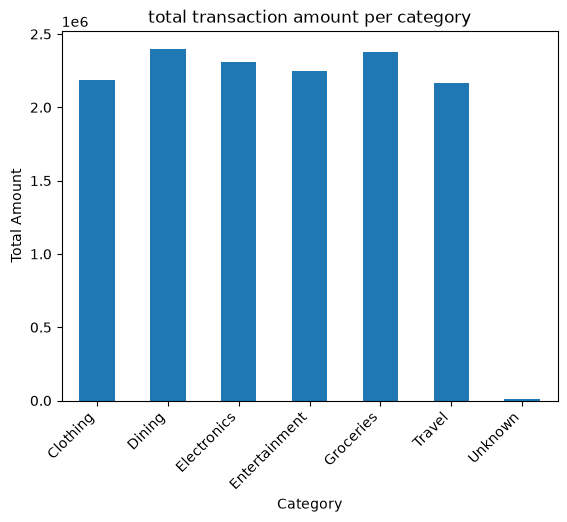

In [46]:
import matplotlib.pyplot as plt

data.groupby("Category")["Amount"].sum().plot(kind="bar")

plt.title("total transaction amount per category")
plt.xlabel("Category")
plt.ylabel("Total Amount")
plt.xticks(rotation=45,ha="right")
plt.show()

C:\Users\Priyank\AppData\Local\Temp\ipykernel_6884\3131741716.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(total_amount_per_category,x="Category",y="Amount",palette="viridis")


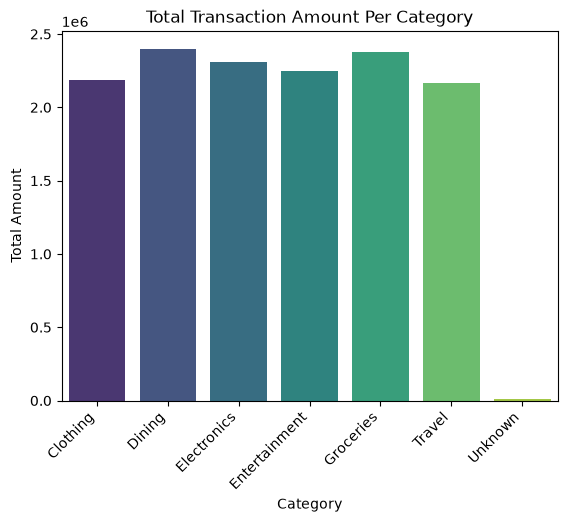

In [48]:
import seaborn as sns

sns.barplot(total_amount_per_category,x="Category",y="Amount",palette="viridis")
plt.title("Total Transaction Amount Per Category")
plt.xlabel("Category")
plt.ylabel("Total Amount")
plt.xticks(rotation=45,ha="right")
plt.show()

*Generate a heatmap showing correlation between Amount, Transaction_Status, and Payment_Mode.